# Objectif du fichier

Analyse descriptive des résultats du clusturing selon les années.
Pour cela plusieurs étapes:
- on récupères les données clusterisées.
- on calcule les différentes métriques pour chaque années.
- on passe à l'année suivante.

Les métriques d'intérêt pour les statistiques descriptives sont : évolution de la surface industrialisée, évolution du nombre de clusters, proportion des bâtiments isolés, nombre de meta clusters, taux de conversion d'une année sur l'autre des points isolés en cluster.

In [1]:
!pip install geopandas pandas numpy shapely matplotlib requests beautifulsoup4 boto3 py7zr

In [2]:
### TELECHARGEMENT PACKAGES
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import re
import os
import subprocess
import boto3
import tempfile
import py7zr 
import glob
from credentials import s3
from fonctions import load_gpkg, gdf_DBSCAN, plot_DB_epsilon#, courbe_DB_epsilon
from fonctions import download_to_SSPCloud

In [3]:
gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg")
gdf['Dep'] = gdf['Dep'].astype(int)
#gdf=gdf[gdf['Dep'].isin([71,63,74,77,67,73,68,76,69])]

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg ...
Chargement réussi (6335672 lignes)


In [76]:
#gdf=gdf[gdf['Annee'].isin([2008,2014,2020,2025])]
#sauv=gdf.copy()
gdf=sauv.copy()

In [64]:
gdf[gdf['Annee']<2019]['ORIGIN_BAT'].unique()

array([], dtype=object)

In [78]:
gdf = gdf[
    (gdf["Dep"] == 62) #& 
    #(gdf["ORIGIN_BAT"].isin(["Imagerie aérienne", "BDTopo"]))
    #(gdf["ORIGIN_BAT"].isin(["Cadastre"])) 
]

gdf=gdf[gdf.geometry.area > 1000].copy()
#gdf=gdf[gdf["Dep"] == 62]

## Etude du panel

On constate un effondrement en 2019 : passage de BDTOPO 2 à 3, mais pas de souci en 2012

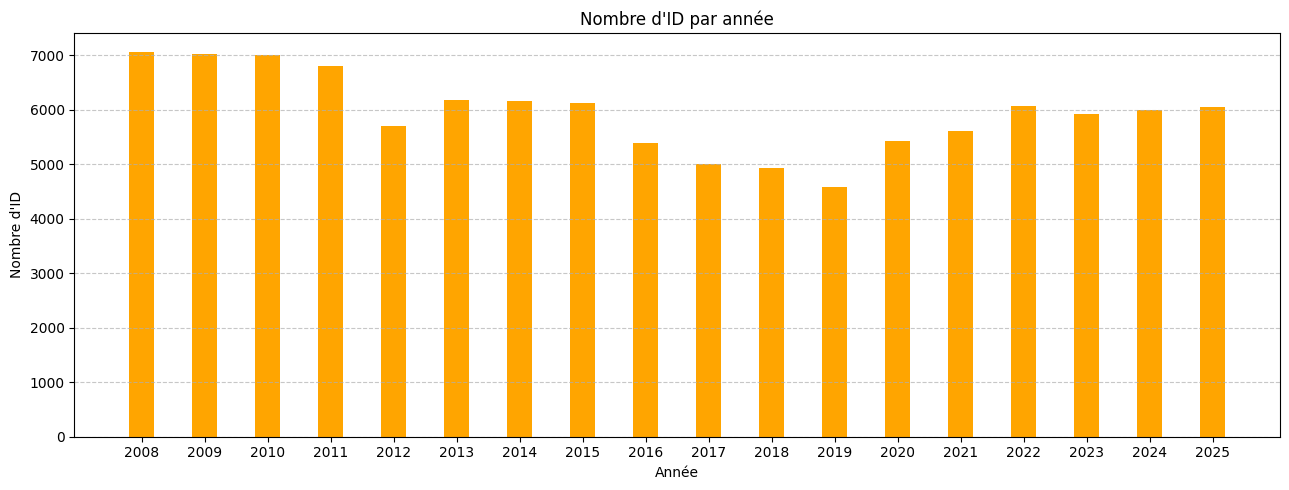

In [79]:
counts = gdf.groupby('Annee')['ID'].count() # ou .count() si tu veux compter les lignes
counts_large = gdf[gdf.geometry.area > 1000].groupby('Annee')['ID'].count() 

# Afficher le graphique
plt.figure(figsize=(13,5))
#plt.bar(counts.index, counts.values, width=0.4, label='Tous', color='skyblue')
plt.bar(counts_large.index, counts_large.values, width=0.4, label='U2', color='orange')
plt.title("Nombre d'ID par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'ID")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(counts.index)
plt.tight_layout()
plt.show()

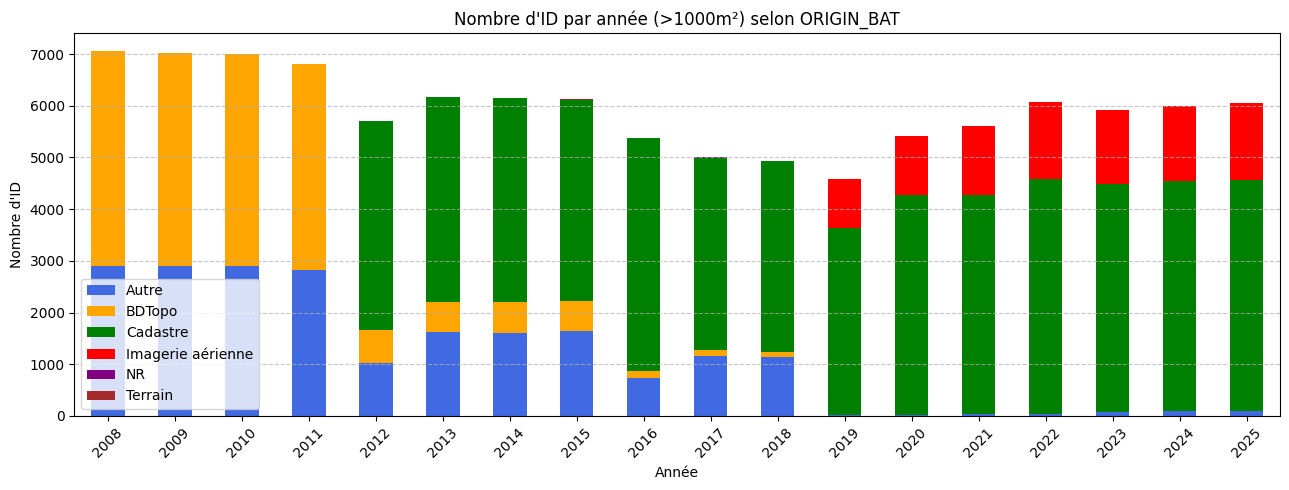

In [103]:
counts = gdf.groupby(['Annee', 'ORIGIN_BAT'])['ID'].count().unstack(fill_value=0)

color_map = {
    "Autre": "royalblue",
    "BDTopo": "orange",
    "Cadastre": "green",
    "Imagerie aérienne": "red",
    "NR": "purple",
    "Terrain": "brown"
}

counts.plot(kind='bar', stacked=True, figsize=(13,5), color=color_map)


plt.title("Nombre d'ID par année (>1000m²) selon ORIGIN_BAT")
plt.xlabel("Année")
plt.ylabel("Nombre d'ID")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

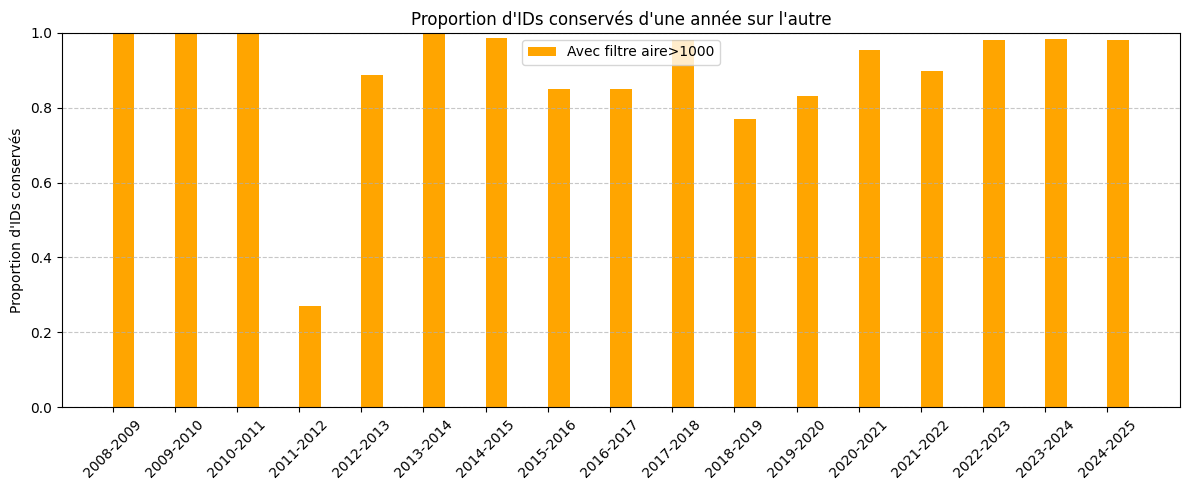

In [89]:
def calcul_retention(df):
    annees = sorted(df['Annee'].unique())
    retention = {}

    for i in range(len(annees) - 1):
        annee_prev = annees[i]
        annee_t = annees[i + 1]

        ids_prev = set(df.loc[df['Annee'] == annee_prev, 'ID'])
        ids_t = set(df.loc[df['Annee'] == annee_t, 'ID'])

        # proportion des IDs en t déjà présentes en t-1
        proportion = len(ids_t & ids_prev) / len(ids_t) if len(ids_t) > 0 else None

        retention[f"{annees[i]}-{annees[i+1]}"] = proportion

    return retention


retention_full = calcul_retention(gdf)

df_retention = pd.DataFrame({
    "Transition": list(retention_full.keys()),
    "Avec_filtre": list(retention_full.values())
})

#plot
x = range(len(df_retention))
width = 0.35
plt.figure(figsize=(12,5))
plt.bar([i + width/2 for i in x], df_retention["Avec_filtre"], width=width, label='Avec filtre aire>1000',  color='orange')
plt.xticks(x, df_retention["Transition"], rotation=45)
plt.ylabel("Proportion d'IDs conservés")
plt.title("Proportion d'IDs conservés d'une année sur l'autre")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_93909/2750132698.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_plot = pd.DataFrame(index=transitions, columns=origins_order).fillna(0)
/tmp/ipykernel_93909/2750132698.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4099387726043002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_plot.at[transitions[i], origin] = count_origin / len(ids_t)  # proportion sur t
/tmp/ipykernel_93909/2750132698.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5863591057952442' has dtype incompatible with int64, please explicitly cast to a compatible

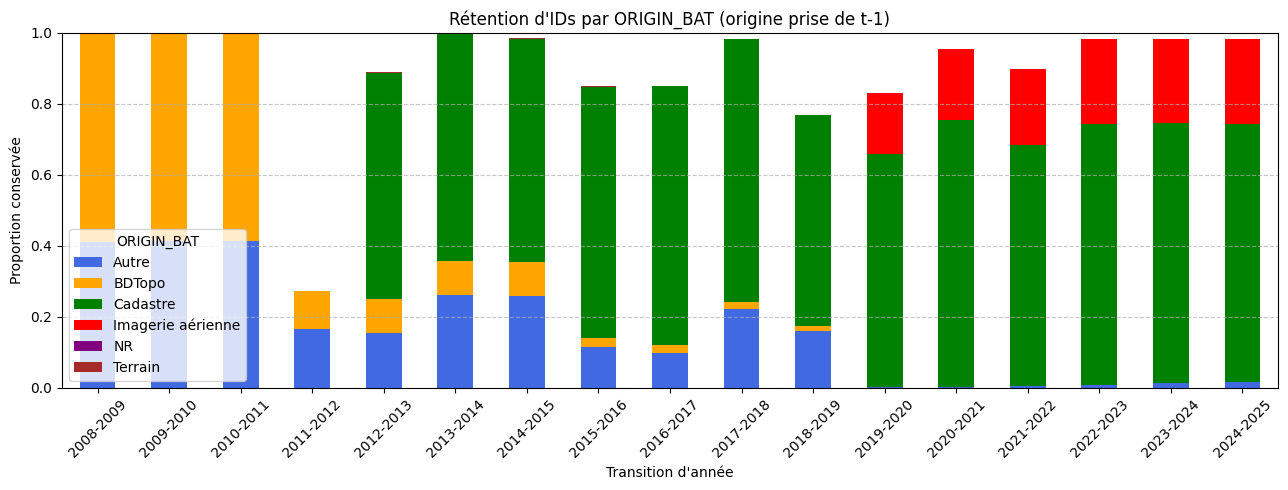

In [ ]:
# Liste des ORIGIN_BAT dans l'ordre souhaité
origins_order = list(color_map.keys())

# Liste des transitions
transitions = list(calcul_retention(gdf).keys())

# DataFrame pour stocker les parts par ORIGIN_BAT
df_plot = pd.DataFrame(index=transitions, columns=origins_order).fillna(0)

for i in range(len(transitions)):
    annee_prev, annee_t = map(int, transitions[i].split('-'))

    gdf_prev = gdf[gdf['Annee'] == annee_prev]
    gdf_t = gdf[gdf['Annee'] == annee_t]

    ids_t = set(gdf_t['ID'])
    ids_prev = set(gdf_prev['ID'])

    # IDs conservées
    retained_ids = ids_t & ids_prev

    if retained_ids:
        for origin in origins_order:
            ids_origin = set(gdf_prev[gdf_prev['ORIGIN_BAT'] == origin]['ID'])
            count_origin = len(retained_ids & ids_origin)
            df_plot.at[transitions[i], origin] = count_origin / len(ids_t)  # proportion sur t

# --- Plot stacked bar avec couleurs fixes ---
ax = df_plot[origins_order].plot(kind='bar', stacked=True, figsize=(13,5),
                                 color=[color_map[origin] for origin in origins_order])

plt.title("Rétention d'IDs par ORIGIN_BAT (origine prise de t-1)")
plt.xlabel("Transition d'année")
plt.ylabel("Proportion conservée")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="ORIGIN_BAT", loc='lower left')
plt.tight_layout()
plt.show()


In [75]:
import pandas as pd

def retention_par_departement(gdf, annee_pair, rayon=50):
    annee_t, annee_t1 = annee_pair
    df_pair = gdf[gdf['Annee'].isin([annee_t, annee_t1])].copy()

    retention_dict = {}
    for dep, group in df_pair.groupby('Dep'):
        # On suppose que 'calcul_retention' existe et retourne un dict avec clé "AAAA-BBBB"
        retention = calcul_retention(group)
        key = f"{annee_t}-{annee_t1}"
        retention_dict[dep] = retention.get(key, None)

    df_retention = pd.DataFrame({
        "DEP": list(retention_dict.keys()),
        f"Proportion_{annee_t}-{annee_t1}": list(retention_dict.values())
    })
    return df_retention


temp = gdf[gdf.geometry.area > 1000].copy()

# Calcul pour les deux paires
df_1718 = retention_par_departement(temp, (2014, 2015))
df_1819 = retention_par_departement(temp, (2018, 2019))
df_1920 = retention_par_departement(temp, (2010, 2011))

# Fusionner les deux résultats par département
df_retention_dep = df_1819.merge(df_1718, on="DEP", how="outer") \
                           .merge(df_1920, on="DEP", how="outer")
df_retention_dep = df_retention_dep.sort_values(by="Proportion_2018-2019", ascending=False).reset_index(drop=True)

print(df_retention_dep)


   DEP  Proportion_2018-2019  Proportion_2014-2015  Proportion_2010-2011
0   62              0.737882              0.978437                   NaN


On calcul le taux de rétention cumulé (mieux que le graph précédent qui est le taux de survie) 

    Annee  Rétention_ID_t-1  Rétention_geo_t-1  Rétention_geo_cumul
0    2009               NaN                NaN                  NaN
1    2010               NaN                NaN                  NaN
2    2011               NaN                NaN                  NaN
3    2012          0.000000           0.000000             0.000000
4    2013          0.998770           0.999590             0.999590
5    2014          0.999113           0.999546             0.999546
6    2015          0.998820           0.999563             0.999563
7    2016          0.792362           0.795056             0.795056
8    2017          0.971447           0.986004             0.986022
9    2018          0.974374           0.982612             0.982928
10   2019          0.633066           0.794894             0.796684
11   2020          0.701004           0.747016             0.938762
12   2021          0.979660           0.993220             0.996277
13   2022          0.790120           0.848085  

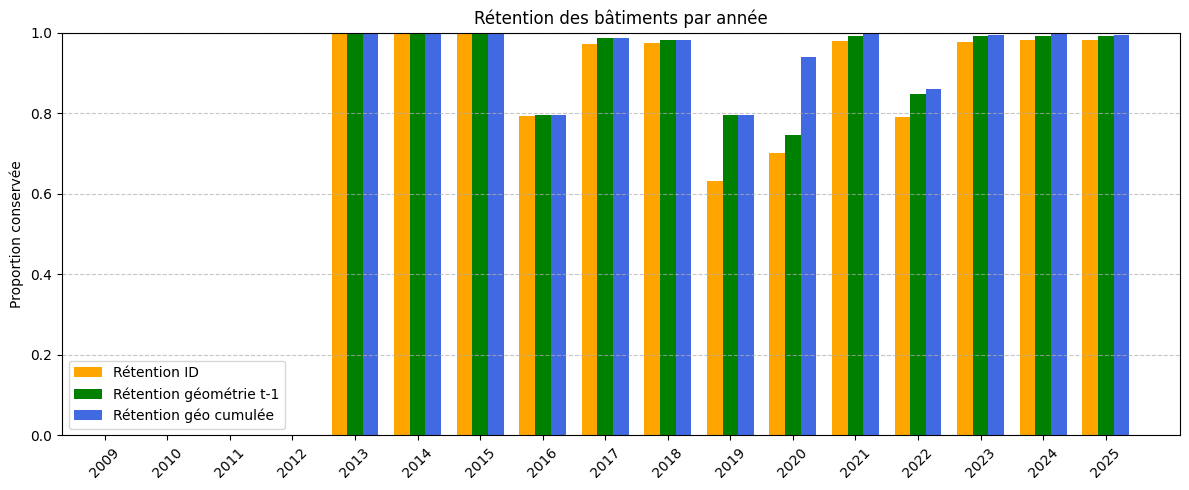

In [ ]:
results = []
rayon = 50
use_cumul = True

for i in range(1, len(annees)):
    annee_t = annees[i]
    annee_prev = annees[i-1]
    
    # DataFrames pour l'année t et t-1
    gdf_t = gdf[gdf['Annee'] == annee_t].copy()
    gdf_prev = gdf[gdf['Annee'] == annee_prev].copy()
    gdf_all_prev = gdf[gdf['Annee'] < annee_t].copy()  # toutes les années < t

    #Rétention par ID ---
    ids_t = set(gdf_t['ID'])
    ids_prev = set(gdf_prev['ID'])
    retention_id = len(ids_t & ids_prev) / len(ids_t) if ids_t else None

    #Rétention géographique année précédente ---
    sindex_prev = gdf_prev.sindex
    count_geo_prev = 0
    for geom in gdf_t.geometry:
        candidates = list(sindex_prev.intersection(geom.buffer(rayon).bounds))
        possible_matches = gdf_prev.iloc[candidates]
        if any(possible_matches.distance(geom) <= rayon):
            count_geo_prev += 1
    retention_geo_prev = count_geo_prev / len(gdf_t) if len(gdf_t) > 0 else None

    #rétention géo cumulée (EN OPTION)
    if use_cumul:
        gdf_all_prev = gdf[gdf['Annee'] < annee_t].copy()
        sindex_all_prev = gdf_all_prev.sindex

        count_geo_cumul = 0
        for geom in gdf_t.geometry:
            candidates = list(sindex_all_prev.intersection(geom.buffer(rayon).bounds))
            possible_matches = gdf_all_prev.iloc[candidates]
            if any(possible_matches.distance(geom) <= rayon):
                count_geo_cumul += 1

        retention_geo_cumul = count_geo_cumul / len(gdf_t) if len(gdf_t) > 0 else None
    else:
        retention_geo_cumul = None

    results.append({
        'Annee': annee_t,
        'Rétention_ID_t-1': retention_id,
        'Rétention_geo_t-1': retention_geo_prev,
        'Rétention_geo_cumul': retention_geo_cumul
    })

df_retention_inverse = pd.DataFrame(results)
print(df_retention_inverse)


#plot
df_plot = df_retention_inverse.copy()
x = range(len(df_plot))
width = 0.25
plt.figure(figsize=(12,5))
plt.bar([i - width for i in x], df_plot['Rétention_ID_t-1'], width=width, label='Rétention ID', color='orange')
plt.bar(x, df_plot['Rétention_geo_t-1'], width=width, label='Rétention géométrie t-1', color='green')
plt.bar([i + width for i in x], df_plot['Rétention_geo_cumul'].fillna(0), width=width, color='royalblue', label='Rétention géo cumulée')
plt.xticks(x, df_plot['Annee'], rotation=45)
plt.ylabel("Proportion conservée")
plt.ylim(0,1)
plt.title("Rétention des bâtiments par année")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


## Clustering

In [5]:
plot_DB_epsilon(gdf,2008,4,1,301,20)

Progress: 13/15 | eps : 241, clusters : 0.680, isolés : 0.320


KeyboardInterrupt: 

In [25]:
#######
####### ON FIXE LES PARAMETRES : A MODIFIER
#######

epsilon_petit = 50
epsilon_grand = 1000
m_sample = 4

On segmente par groupes de 20 départements. On fait tout le process et on stocke. Puis à la fin on aggrège selon tous les départements. Pour les proportions, l'aggrégation se fait à la fin.

In [26]:
####Fonction meta cluster : test en local avant de mettre dans fonctions

import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.cluster import DBSCAN

def gdf_meta_DBSCAN(gdf: gpd.GeoDataFrame,
                    annee: int,
                    eps1: float,
                    eps2: float,
                    min_sample: int = 4):
    # 1) Filtre année
    gdf_annee = gdf[gdf["Annee"] == annee].copy()
    if len(gdf_annee) == 0:
        gdf_annee["centroid"] = pd.Series(dtype="object")
        gdf_annee["id_cluster"] = pd.Series(dtype="int64")
        gdf_annee["id_meta_cluster"] = pd.Series(dtype="int64")
        return gdf_annee, dict(n_clusters_lvl1=0, n_noise_lvl1=0,
                               n_meta_clusters=0, n_meta_noise=0)

    # 2) CRS métrique
    if gdf_annee.crs is None or not gdf_annee.crs.is_projected:
        gdf_annee = gdf_annee.to_crs(2154)

    # 3) Centroids
    gdf_annee["centroid"] = gdf_annee.geometry.centroid
    coords = np.column_stack([gdf_annee["centroid"].x.values,
                              gdf_annee["centroid"].y.values])

    # 4) DBSCAN niveau 1
    db1 = DBSCAN(eps=eps1, min_samples=min_sample)
    labels1 = db1.fit_predict(coords)
    gdf_annee["id_cluster"] = labels1.astype(int)

    n_clusters_lvl1 = int(len(set(labels1)) - (1 if -1 in labels1 else 0))
    n_noise_lvl1 = int(np.sum(labels1 == -1))

    # 5) Barycentres (clusters != -1)
    mask_clusters = (gdf_annee["id_cluster"].values != -1)  # <-- bool np.array
    if mask_clusters.any():
        df_centroids = (
            gdf_annee.loc[mask_clusters, ["id_cluster", "centroid"]]
            .assign(x=lambda d: d["centroid"].x,
                    y=lambda d: d["centroid"].y)
            .groupby("id_cluster", as_index=False)[["x", "y"]].mean()
        )

        # 6) DBSCAN niveau 2 sur barycentres (ceux des 

        bary_coords = np.column_stack([df_centroids["x"].values, df_centroids["y"].values])
        db2 = DBSCAN(eps=eps2, min_samples=min_sample)
        labels2 = db2.fit_predict(bary_coords)

        # 7) Remappage des labels de méta-clusters en 0..K-1 (en conservant -1)
        uniq = sorted([l for l in set(labels2) if l != -1])
        remap = {old: new for new, old in enumerate(uniq)}
        meta_labels = pd.Series(labels2).map(remap).fillna(-1).astype(int).to_numpy()

        # 8) Propagation aux entités d'origine
        meta_map = dict(zip(df_centroids["id_cluster"].astype(int).tolist(),
                            meta_labels.tolist()))
        gdf_annee["id_meta_cluster"] = gdf_annee["id_cluster"].map(meta_map).fillna(-1).astype(int)

        # Les bruits niveau 1 restent -1 (sans .loc avec ~mask ; approche .where)
        gdf_annee["id_meta_cluster"] = gdf_annee["id_meta_cluster"].where(
            gdf_annee["id_cluster"] != -1, -1
        ).astype(int)

        n_meta_clusters = int(len(uniq))
        n_meta_noise = int(np.sum(labels2 == -1))
    else:
        # Aucun cluster niveau 1
        gdf_annee["id_meta_cluster"] = -1
        n_meta_clusters, n_meta_noise = 0, 0

    # (optionnel) logs
    print(f"[Niveau 1] Clusters: {n_clusters_lvl1} | Bruit: {n_noise_lvl1}")
    print(f"[Niveau 2] Méta-clusters: {n_meta_clusters} | Bruit (barycentres): {n_meta_noise}")

    return gdf_annee, dict(
        n_clusters_lvl1=n_clusters_lvl1,
        n_noise_lvl1=n_noise_lvl1,
        n_meta_clusters=n_meta_clusters,
        n_meta_noise=n_meta_noise
    )


        


#### TEST

test , stat = gdf_meta_DBSCAN(gdf,
                    annee =  2008,
                    eps1 =  50,
                    eps2 =  1000,
                    min_sample= 5)

[Niveau 1] Clusters: 1380 | Bruit: 164798
[Niveau 2] Méta-clusters: 26 | Bruit (barycentres): 1104


In [83]:
stat["n_clusters_lvl1"]

8849

In [ ]:
#### département 1 à 20

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf1 = []
nbclust1 = []
nbmeta1 = []
nbisole1 = []
nbconv1 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat1 = []
for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf1.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust1.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta1.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole1.append(stat["n_noise_lvl1"])

    ## nb batiments
    nbbat1.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    # On commence par merger gdf meta et meta moins1 sur id pour rajouter l'id clu
    gdf_meta_moins1.rename(columns={"id_cluster": "id_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_cluster_moins"]], on="ID", how="left")
    nbconv1.append(len(gdf_meta[(gdf_meta.id_cluster != -1) & (gdf_meta.id_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_cluster_moins == -1]))



In [89]:
#### département 21 à 40

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_21_40.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf2 = []
nbclust2 = []
nbmeta2 = []
nbisole2 = []
nbconv2 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf2.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust2.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta2.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole2.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_cluster": "id_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_cluster_moins"]], on="ID", how="left")
    nbconv2.append(len(gdf_meta[(gdf_meta.id_cluster != -1) & (gdf_meta.id_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_cluster_moins == -1]))

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_21_40.gpkg ...
Chargement réussi (5532961 lignes)
[Niveau 1] Clusters: 10272 | Bruit: 346627
[Niveau 2] Méta-clusters: 403 | Bruit (barycentres): 7110
[Niveau 1] Clusters: 9350 | Bruit: 346752
[Niveau 2] Méta-clusters: 369 | Bruit (barycentres): 6720
[Niveau 1] Clusters: 10927 | Bruit: 345651
[Niveau 2] Méta-clusters: 442 | Bruit (barycentres): 7369
[Niveau 1] Clusters: 10272 | Bruit: 346627
[Niveau 2] Méta-clusters: 403 | Bruit (barycentres): 7110
[Niveau 1] Clusters: 11654 | Bruit: 348889
[Niveau 2] Méta-clusters: 493 | Bruit (barycentres): 7626
[Niveau 1] Clusters: 10927 | Bruit: 345651
[Niveau 2] Méta-clusters: 442 | Bruit (barycentres): 7369
[Niveau 1] Clusters: 11654 | Bruit: 348889
[Niveau 2] Méta-clusters: 493 | Bruit (barycentres): 7626
[Niveau 1] Clusters: 17012 | Bruit: 317328
[Niveau 2] Méta-clusters: 752 | Bruit (barycentres): 9801
[Niveau 1] Clusters: 18189 | Bruit: 309381
[Niveau 2] Méta-clusters: 804 | Bruit (bar

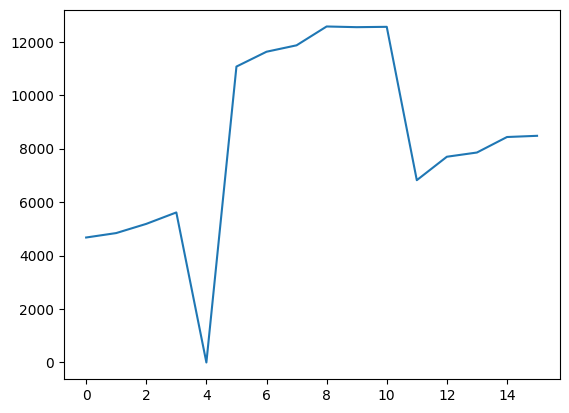

In [93]:
plt.plot(nbclust)

In [94]:
#### département 41 à 60

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_41_60.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf3 = []
nbclust3 = []
nbmeta3 = []
nbisole3 = []
nbconv3 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf3.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust3.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta3.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole3.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_cluster": "id_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_cluster_moins"]], on="ID", how="left")
    nbconv3.append(len(gdf_meta[(gdf_meta.id_cluster != -1) & (gdf_meta.id_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_cluster_moins == -1]))

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_41_60.gpkg ...
Chargement réussi (6183558 lignes)
[Niveau 1] Clusters: 10635 | Bruit: 379440
[Niveau 2] Méta-clusters: 409 | Bruit (barycentres): 7178
[Niveau 1] Clusters: 9976 | Bruit: 381921
[Niveau 2] Méta-clusters: 374 | Bruit (barycentres): 7036
[Niveau 1] Clusters: 11271 | Bruit: 381960
[Niveau 2] Méta-clusters: 417 | Bruit (barycentres): 7689
[Niveau 1] Clusters: 10635 | Bruit: 379440
[Niveau 2] Méta-clusters: 409 | Bruit (barycentres): 7178
[Niveau 1] Clusters: 11310 | Bruit: 378653
[Niveau 2] Méta-clusters: 414 | Bruit (barycentres): 7663
[Niveau 1] Clusters: 11271 | Bruit: 381960
[Niveau 2] Méta-clusters: 417 | Bruit (barycentres): 7689
[Niveau 1] Clusters: 11310 | Bruit: 378653
[Niveau 2] Méta-clusters: 414 | Bruit (barycentres): 7663
[Niveau 1] Clusters: 24365 | Bruit: 331283
[Niveau 2] Méta-clusters: 918 | Bruit (barycentres): 9574
[Niveau 1] Clusters: 24840 | Bruit: 320721
[Niveau 2] Méta-clusters: 943 | Bruit (bar

In [95]:
#### département 61 à 80

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf4 = []
nbclust4 = []
nbmeta4 = []
nbisole4 = []
nbconv4 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf4.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust4.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta4.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole4.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_cluster": "id_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_cluster_moins"]], on="ID", how="left")
    nbconv4.append(len(gdf_meta[(gdf_meta.id_cluster != -1) & (gdf_meta.id_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_cluster_moins == -1]))

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg ...
Chargement réussi (5907821 lignes)
[Niveau 1] Clusters: 8397 | Bruit: 322980
[Niveau 2] Méta-clusters: 340 | Bruit (barycentres): 5142
[Niveau 1] Clusters: 7488 | Bruit: 324000
[Niveau 2] Méta-clusters: 293 | Bruit (barycentres): 4935
[Niveau 1] Clusters: 10988 | Bruit: 331479
[Niveau 2] Méta-clusters: 420 | Bruit (barycentres): 6167
[Niveau 1] Clusters: 8397 | Bruit: 322980
[Niveau 2] Méta-clusters: 340 | Bruit (barycentres): 5142
[Niveau 1] Clusters: 14236 | Bruit: 319104
[Niveau 2] Méta-clusters: 575 | Bruit (barycentres): 6576
[Niveau 1] Clusters: 10988 | Bruit: 331479
[Niveau 2] Méta-clusters: 420 | Bruit (barycentres): 6167
[Niveau 1] Clusters: 14236 | Bruit: 319104
[Niveau 2] Méta-clusters: 575 | Bruit (barycentres): 6576
[Niveau 1] Clusters: 18165 | Bruit: 296559
[Niveau 2] Méta-clusters: 781 | Bruit (barycentres): 7387
[Niveau 1] Clusters: 19106 | Bruit: 294409
[Niveau 2] Méta-clusters: 842 | Bruit (baryc

In [205]:
#### département 81 à 99

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf5 = []
nbclust5 = []
nbmeta5 = []
nbisole5 = []
nbconv5 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat5 = []

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des indus
    surf5.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust5.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta5.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole5.append(stat["n_noise_lvl1"])

    ## nb bat 
    nbbat5.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_cluster": "id_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_cluster_moins"]], on="ID", how="left")
    nbconv5.append(len(gdf_meta[(gdf_meta.id_cluster != -1) & (gdf_meta.id_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_cluster_moins == -1]))

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg ...
Chargement réussi (2958999 lignes)
[Niveau 1] Clusters: 4225 | Bruit: 156798
[Niveau 2] Méta-clusters: 163 | Bruit (barycentres): 2465
[Niveau 1] Clusters: 3975 | Bruit: 152972
[Niveau 2] Méta-clusters: 158 | Bruit (barycentres): 2303
[Niveau 1] Clusters: 4778 | Bruit: 157479
[Niveau 2] Méta-clusters: 178 | Bruit (barycentres): 2587
[Niveau 1] Clusters: 4225 | Bruit: 156798
[Niveau 2] Méta-clusters: 163 | Bruit (barycentres): 2465
[Niveau 1] Clusters: 6856 | Bruit: 149663
[Niveau 2] Méta-clusters: 237 | Bruit (barycentres): 2591
[Niveau 1] Clusters: 4778 | Bruit: 157479
[Niveau 2] Méta-clusters: 178 | Bruit (barycentres): 2587
[Niveau 1] Clusters: 6856 | Bruit: 149663
[Niveau 2] Méta-clusters: 237 | Bruit (barycentres): 2591
[Niveau 1] Clusters: 8849 | Bruit: 148864
[Niveau 2] Méta-clusters: 312 | Bruit (barycentres): 3555
[Niveau 1] Clusters: 9604 | Bruit: 148200
[Niveau 2] Méta-clusters: 325 | Bruit (barycentres

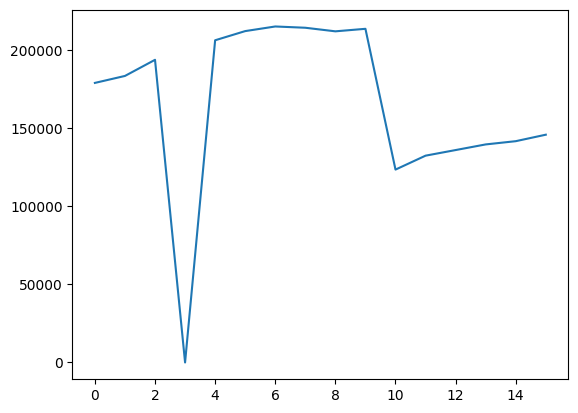

In [207]:
plt.plot(nbbat5)

In [82]:
#### Code à intégrer au précédent : transition d'isolé à cluster d'une année sur l'autre
## On joint la colonne id_cluster de l'année -1 sur la colonne id, et on garde les observations qui étaient à -1 l'année passée et différent de -1 sur l'année suivnate.

df_conv = gdf_meta.merge(gdf_meta_moins1["ID", "id_cluster"], on="ID", how="left", suffixes=("", "_ancien")) ## gdf qui contient aussi l'information sur la bat était un cluster l'année précédente
nbconv1.append(len(df_conv[ (df_conv["id_cluster"]!=-1) & (df_conv["id_cluster_ancien"]==-1),:])) ## On compte tous les bat qui passent d'isolé à cluster 


{'n_clusters_lvl1': 8849,
 'n_noise_lvl1': 148864,
 'n_meta_clusters': 312,
 'n_meta_noise': 3555}

In [98]:
##### On somme et on fait les statistiques descriptives

## nombre clusters
nbclust = [sum(x) for x in zip(nbclust1, nbclust2, nbclust3, nbclust4, nbclust5)]

## nombre de meta clusters
nbmeta = [sum(x) for x in zip(nbmeta1, nbmeta2, nbmeta3, nbmeta4, nbmeta5)]

## surface totale
surf = [sum(x) for x in zip(surf1, surf2, surf3, surf4, surf5)]

## nombre d'isolés
nbisole = [sum(x) for x in zip(nbisole1, nbisole2, nbisole3, nbisole4, nbisole5)]

## Nombre de conversions


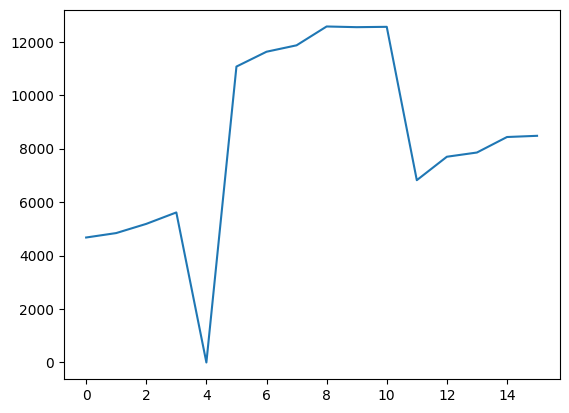

In [208]:
plt.plot(nbclust1)

## Calcul des paramètres optimaux epsilon et min_sample
Pour chaque valeur de min_sample, on cherche le maximum de la dérivée seconde, cela nous permet donc de déduire le meilleur epsilon. On cherche ensuite le min_sample qui mène au coude le plus prononcé. On a ainsi la meilleure paire

In [250]:
def derivee_seconde(y, dt=1):
    y = np.array(y, dtype=float)
    d2y = np.gradient(np.gradient(y, dt), dt)
    return d2y


import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

def dbscan_elbow(gdf, minPts=5, title="Méthode du coude pour DBSCAN"):
    # 1️⃣ Vérification des données
    if 'geometry' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")

    # 2️⃣ Reprojeter en coordonnées métriques si nécessaire (pour distances physiques)
    if gdf.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un système de coordonnées défini (CRS).")
    if not gdf.crs.is_projected:
        print("⚠️ Projection en EPSG:3857 pour obtenir des distances en mètres.")
        gdf = gdf.to_crs(epsg=3857)

    # 3️⃣ Extraire les coordonnées des points
    coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))

    # 4️⃣ Calcul du k-ième voisin
    k = minPts - 1
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # 5️⃣ Trier les distances du k-ième plus proche voisin
    distances = np.sort(distances[:, k-1])

    # 6️⃣ Tracer la courbe du coude
    plt.figure(figsize=(8, 5))
    plt.plot(distances)
    plt.title(f"{title} (k = {k})")
    plt.xlabel("Points triés par distance croissante")
    plt.ylabel(f"Distance au {k}-ième plus proche voisin (mètres)")
    plt.grid(True)
    plt.show()

    return distances

def dbscan_elbow_courbe(gdf, minPts=5, title="Méthode du coude pour DBSCAN"):
    # 1️⃣ Vérification des données
    if 'geometry' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")

    # 2️⃣ Reprojeter en coordonnées métriques si nécessaire (pour distances physiques)
    if gdf.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un système de coordonnées défini (CRS).")
    if not gdf.crs.is_projected:
        print("⚠️ Projection en EPSG:3857 pour obtenir des distances en mètres.")
        gdf = gdf.to_crs(epsg=3857)

    # 3️⃣ Extraire les coordonnées des points
    coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))

    # 4️⃣ Calcul du k-ième voisin
    k = minPts - 1
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # 5️⃣ Trier les distances du k-ième plus proche voisin
    distances = np.sort(distances[:, k-1])

    # 6️⃣ Tracer la courbe du coude
    plt.figure(figsize=(8, 5))
    plt.plot(distances)
    plt.xlim(2500000, 3000000) 
    plt.title(f"{title} (k = {k+1})")
    plt.xlabel("Points triés par distance croissante")
    plt.xscale("log")
    plt.ylabel(f"Distance au {k}-ième plus proche voisin (mètres)")
    plt.grid(True)
    plt.show()

    return distances

def dbscan_elbow_courbe_meta(gdf, minPts=5, title="Méthode du coude pour DBSCAN Meta"):
    # 1️⃣ Vérification des données
    if 'barycentre' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")

    # 2️⃣ Reprojeter en coordonnées métriques si nécessaire (pour distances physiques)
    if gdf.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un système de coordonnées défini (CRS).")
    if not gdf.crs.is_projected:
        print("⚠️ Projection en EPSG:3857 pour obtenir des distances en mètres.")
        gdf = gdf.to_crs(epsg=3857)

    # 3️⃣ Extraire les coordonnées des points
    coords = np.unique(np.array(list(zip(gdf.barycentre.x, gdf.barycentre.y))),axis = 0)

    # 4️⃣ Calcul du k-ième voisin
    k = minPts - 1
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # 5️⃣ Trier les distances du k-ième plus proche voisin
    distances = np.sort(distances[:, k-1])

    # 6️⃣ Tracer la courbe du coude
    plt.figure(figsize=(8, 5))
    plt.plot(distances)
    plt.title(f"{title} (k = {k+1})")
    plt.xlabel("Points triés par distance croissante")
    plt.xscale("log")
    plt.ylabel(f"Distance au {k}-ième plus proche voisin (mètres)")
    plt.grid(True)
    plt.show()

    return distances


In [248]:
coords = np.unique(np.array(list(zip(gdf_meta_clust.barycentre.x, gdf_meta_clust.barycentre.y))),axis = 0)

# 4️⃣ Calcul du k-ième voisin
k = 4
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(coords)
distances, indices = nbrs.kneighbors(coords)

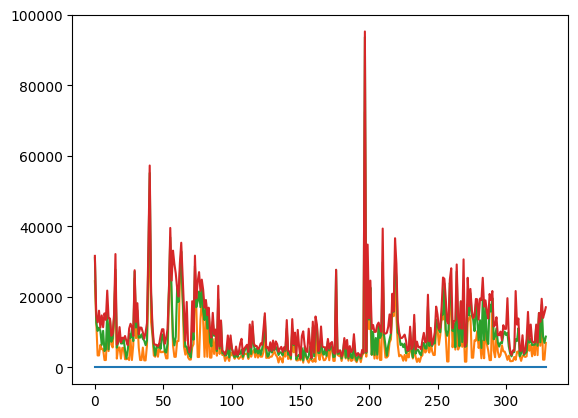

In [249]:
plt.plot(distances)

In [245]:
np.unique(coords,axis = 0)

array([[ 301516.06807222, 6665754.003794  ],
       [ 314792.12339083, 6645173.86669964],
       [ 322556.01700964, 6634999.88490668],
       [ 325313.71966969, 6632991.51332249],
       [ 327538.2255317 , 6644078.08411359],
       [ 328590.14682448, 6650401.62331748],
       [ 331232.6546329 , 6654877.84784028],
       [ 332888.54560452, 6611114.23308888],
       [ 333501.47618614, 6613128.84038298],
       [ 334912.86613509, 6664593.1045019 ],
       [ 337311.08794905, 6609702.97026907],
       [ 343609.77470272, 6622086.43397322],
       [ 354862.29821445, 6629802.17103691],
       [ 356952.35226936, 6639219.74025479],
       [ 358030.94124405, 6658974.85443629],
       [ 359477.63529202, 6593017.69488317],
       [ 360658.51359874, 6626872.27308897],
       [ 361649.76470496, 6632412.88723234],
       [ 362066.78123003, 6641683.2509081 ],
       [ 362665.57630213, 6625353.71303837],
       [ 369053.32996155, 6627722.84920685],
       [ 369776.64106784, 6633223.4507892 ],
       [ 3

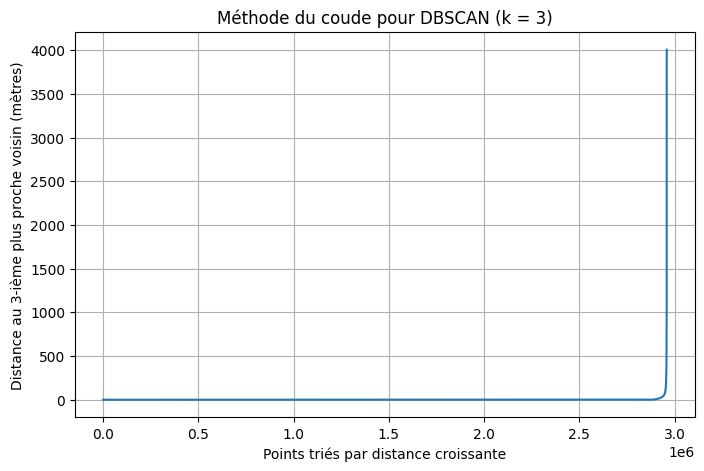

In [136]:
a = dbscan_elbow(gdf,minPts = 4)

(2800000, 3000000)

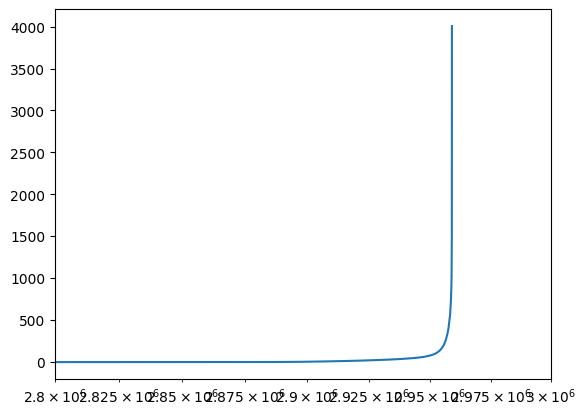

In [137]:
plt.plot(a)
plt.xscale("log")
plt.xlim(2800000, 3000000) 

In [128]:
from sklearn.metrics import silhouette_score

# coords = tableau des coordonnées (x, y)
coords = np.column_stack([test.geometry.centroid.x, test.geometry.centroid.y])
labels = test["id_cluster"]

# on exclut le bruit (-1)
mask = labels != -1
sil_score = silhouette_score(coords[mask], labels[mask])
sil_score

0.8716200031631621

In [139]:
np.gradient(a)

array([  0.        ,   0.        ,   0.        , ...,  87.33824191,
       107.01101051,  56.1143716 ], shape=(2958999,))

In [140]:
import numpy as np

def moving_average(y, window_size=5):
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')


In [178]:
b = moving_average(a,window_size=10000)

In [179]:
c = np.gradient(np.gradient(b))

(2958000.0, 2960000.0)

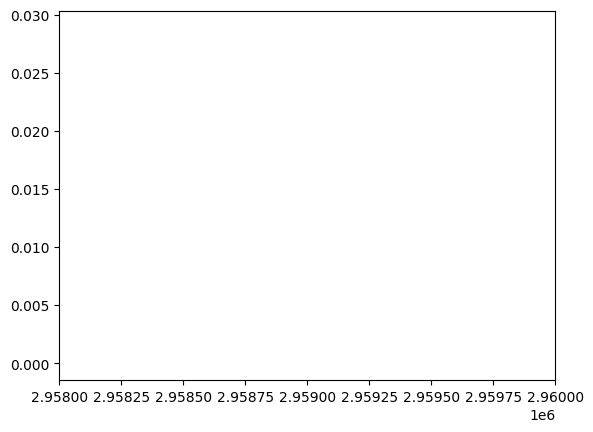

In [181]:
plt.plot(c)
plt.xlim(2958000, 2960000) 

In [182]:
!pip install kneed

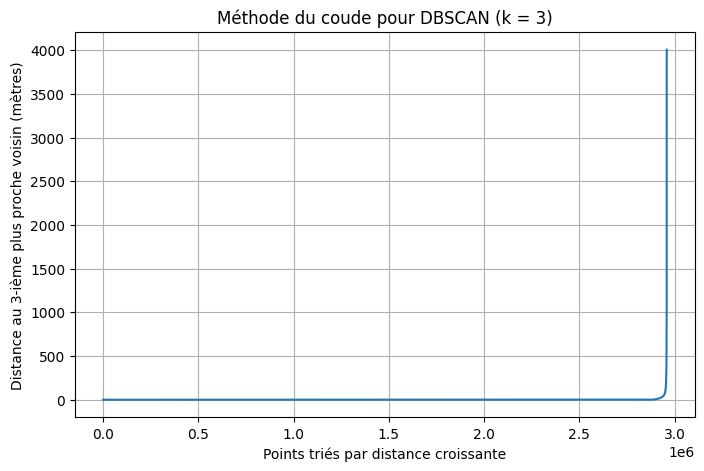

np.float64(1425.500074852785)

In [204]:
from kneed import KneeLocator
a = dbscan_elbow(gdf,minPts = 4)
x = np.arange(1, len(a) + 1)
y = a
knee = KneeLocator(x, y, curve='convex', direction='increasing')
a[knee.knee-1]

In [194]:
knee.knee

np.int64(2958999)

In [222]:
####
#### METHODE DU COUDE SUR LES METACLUSTER
####



def ajouter_barycentre_par_metacluster(gdf, cluster_col="id_meta_cluster"):
    # 1️⃣ Vérifications de base
    if cluster_col not in gdf.columns:
        raise ValueError(f"La colonne '{cluster_col}' n'existe pas dans le GeoDataFrame.")
    if 'geometry' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")
    
    gdf_copy = gdf.copy()
    
    # 2️⃣ Si géométries non projetées, avertir
    if gdf_copy.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un CRS défini pour calculer les barycentres.")
    if not gdf_copy.crs.is_projected:
        print("⚠️ Le CRS n'est pas projeté. Projection temporaire en EPSG:3857 pour le calcul en mètres.")
        gdf_copy = gdf_copy.to_crs(epsg=3857)
    
    # 3️⃣ Calcul des barycentres par groupe
    # Dissolve (fusionne) les géométries par méta-cluster
    barycentres = gdf_copy.dissolve(by=cluster_col, as_index=False)[[cluster_col, "geometry"]]
    
    # Calcul du centroïde de chaque groupe
    barycentres["barycentre"] = barycentres.geometry.centroid
    
    # 4️⃣ Fusion des barycentres avec le gdf original
    gdf_final = gdf_copy.merge(
        barycentres[[cluster_col, "barycentre"]],
        on=cluster_col,
        how="left"
    )
    
    return gdf_final
    

gdf_meta_clust = ajouter_barycentre_par_metacluster(gdf_meta)
dbscan_elbow_courbe_meta(gdf_meta_clust)

AttributeError: 'GeoSeries' object has no attribute 'barycentre'

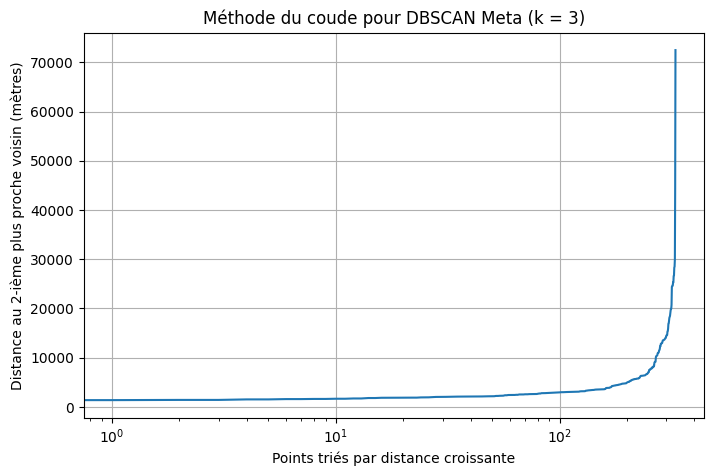

array([ 1363.4326021 ,  1363.4326021 ,  1405.64306939,  1405.64306939,
        1509.78884074,  1509.78884074,  1573.18143766,  1573.18143766,
        1604.37079191,  1604.37079191,  1644.2763151 ,  1644.2763151 ,
        1699.919142  ,  1699.919142  ,  1789.77878741,  1789.77878741,
        1839.93443167,  1839.93443167,  1853.95926162,  1853.95926162,
        1866.52461247,  1866.52461247,  1869.05509131,  1869.05509131,
        1914.59622733,  1914.59622733,  1930.63862401,  1980.09688652,
        2010.78318636,  2010.78318636,  2028.74191894,  2028.74191894,
        2046.50315725,  2046.50315725,  2076.92850568,  2076.92850568,
        2088.66417371,  2088.66417371,  2089.74126829,  2089.74126829,
        2105.78404575,  2105.78404575,  2106.07144962,  2106.07144962,
        2110.71541169,  2110.71541169,  2126.61943847,  2126.61943847,
        2142.91678697,  2142.91678697,  2156.4261721 ,  2156.4261721 ,
        2214.45396757,  2214.45396757,  2243.97538681,  2243.97538681,
      

In [255]:
dbscan_elbow_courbe_meta(gdf_meta_clust,minPts = 3)

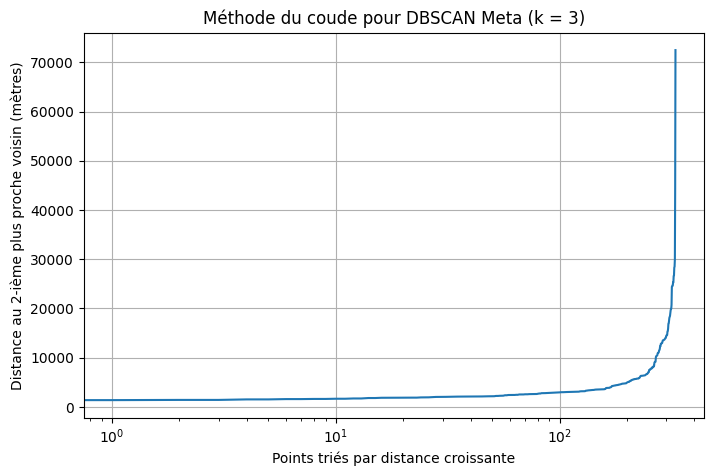

np.float64(24651.665533514366)

In [256]:
from kneed import KneeLocator
a = dbscan_elbow_courbe_meta(gdf_meta_clust,minPts = 3)
x = np.arange(1, len(a) + 1)
y = a
knee = KneeLocator(x, y, curve='convex', direction='increasing')
a[knee.knee-1]

## Métriques de  qualité du cluster

In [195]:
from sklearn.metrics import silhouette_score
#### Silhouette_score

# coords = tableau des coordonnées (x, y)
coords = np.column_stack([test.geometry.centroid.x, test.geometry.centroid.y])
labels = test["id_cluster"]

# on exclut le bruit (-1)
mask = labels != -1
sil_score = silhouette_score(coords[mask], labels[mask])
sil_score

#### 

import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

def grid_search_dbscan(X, eps_list, min_samples_list,
                       max_noise=0.3, min_clusters=2):
    best = None
    results = []
    for ms in min_samples_list:
        for eps in eps_list:
            lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
            n_noise = np.mean(lab == -1)
            n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
            sil = np.nan
            if n_clusters >= min_clusters and n_noise <= max_noise:
                mask = lab != -1
                if mask.sum() > n_clusters:  # au moins 1 point/cluster
                    sil = silhouette_score(X[mask], lab[mask])
            row = dict(eps=eps, min_samples=ms,
                       silhouette=sil, noise=n_noise, n_clusters=n_clusters)
            results.append(row)
            if not np.isnan(sil):
                if best is None or sil > best["silhouette"]:
                    best = row
    return best, results


In [ ]:
Coordo = np.column_stack([
    gdf.geometry.centroid.x,
    gdf.geometry.centroid.y
])

li_ep = [x*40  for x in range(1,100)]
meilleur , swag = grid_search_dbscan(Coordo, eps_list = li_ep, min_samples_list = range(1,20))


# Etude sur la rupture de tendance forte

Pour comprendre pourquoi on a 2 ruptures de tendance, il convient de comprendre ce qui se passe aux deux points clés.
Deux métriques vont être utilisées : 
- le nombre de bâtiments, cela peut expliquer l'effondrement des clusters.
- On va faire un tracking des batiments. On prend tous les batiments présents en 2009 et on voit la proportion de ceux qui le sont encore en n.

In [ ]:
gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")
## Dataframe que l'on va exploiter

## Tracking bâtiments

In [10]:
### On 
gdf[gdf.ID == "BATIMENT0000000051915382"]

,ID,Annee,Dep,ORIGIN_BAT,NATURE,HAUTEUR,USAGE1,USAGE2,ETAT,DATE_CREAT,DATE_MAJ,ID_SOURCE,SOURCE,geometry
0,BATIMENT0000000051915382,2011,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
17870,BATIMENT0000000051915382,2012,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
55489,BATIMENT0000000051915382,2014,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
93974,BATIMENT0000000051915382,2013,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
132606,BATIMENT0000000051915382,2008,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
149353,BATIMENT0000000051915382,2009,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."
167194,BATIMENT0000000051915382,2010,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((636592.3 6317214.3 183.9, 636624.2..."


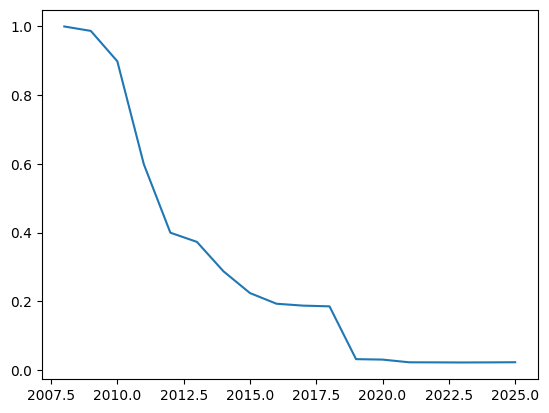

In [18]:
## On prend la liste des bâtiments en 2008
list_2008 = gdf[gdf.Annee == 2008].ID
## On garde que les bats présents en 2008
gdf_8 = gdf[gdf.ID.isin(list_2008)]
gdf_8

prop = []
for an in range(2008,2026):
    prop.append(len(gdf_8[gdf_8.Annee==an])/len(list_2008))

plt.plot(list(range(2008,2026)),prop)

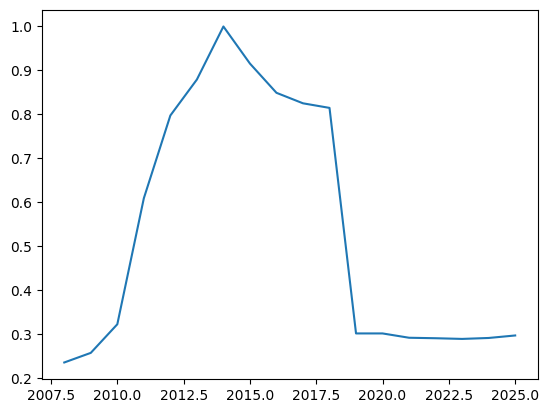

In [22]:
## On prend la liste des bâtiments en 2008
list_2014 = gdf[gdf.Annee == 2014].ID
## On garde que les bats présents en 2016
gdf_14 = gdf[gdf.ID.isin(list_2014)]
gdf_14

prop = []
for an in range(2008,2026):
    prop.append(len(gdf_14[gdf_14.Annee==an])/len(list_2014))

plt.plot(list(range(2008,2026)),prop)

On observe vraiment un effondrement des IDs au moment du changement de base BDTopo. Cependant, on observe aussi un comportement bizarre vers 2010-2011, il faudrait pouvoir le caractériser. On va tracer le nombre de bâtiments pour voir si on a une telle rupture ou si c'est juste une perte de mémoire.

Text(0.5, 1.0, 'Nombre de bâtiments')

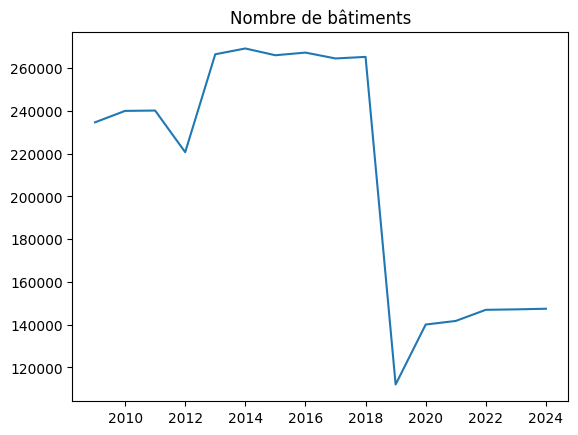

In [41]:
plt.plot(list(range(2009,2025)),nbbat1)
plt.title("Nombre de bâtiments")

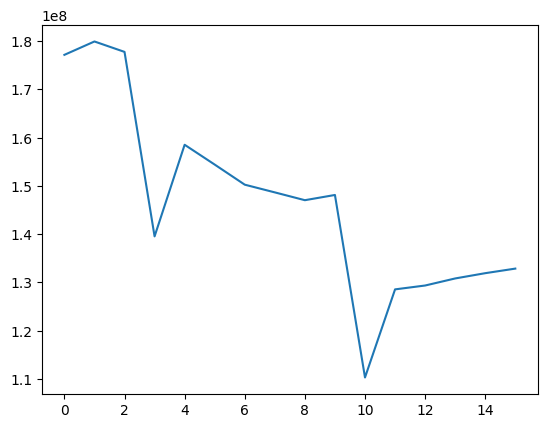

In [32]:
plt.plot(list(range(2009,2025)),surf1)
plt.title("Surface totale")

Il semble que le nombre de batiments soit cohérent (voir un petit rebond en 2010-2011). Il convient cependant de voir s'il n'y a pas eu une redéfinition de la notion de bâtiment. Pour cela tracer la surface moyenne d'un bâtiment.

Text(0.5, 1.0, 'Surface moyenne')

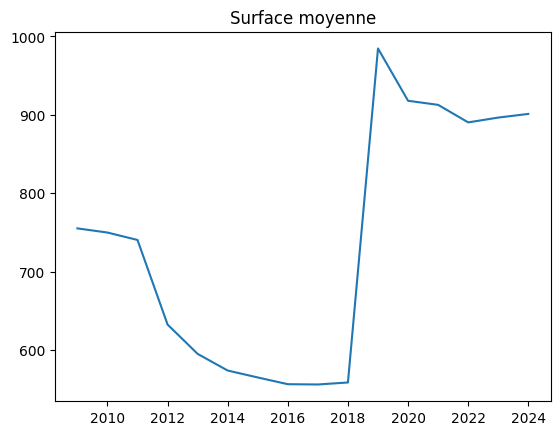

In [42]:
plt.plot(list(range(2009,2025)),np.array(surf1)/np.array(nbbat1))
plt.title("Surface moyenne")

On observe un effondrement de la surface moyenne vers 2010-2011 qui est drivé aussi bien par une baisse de la surface industrialisée, que par une augmentation du nombre de bâtiments.

Text(0.5, 1.0, 'Taux de conversion cluster')

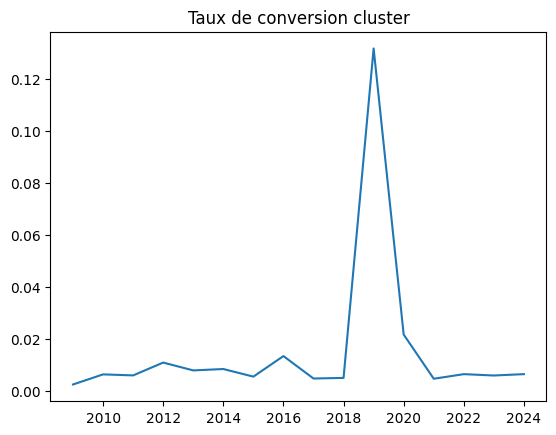

In [50]:
## Taux de conversion
plt.plot(list(range(2009,2025)),nbconv1)
plt.title("Taux de conversion cluster")

# Nouvelle définition du Méta Cluster - Raisonnement sur des batiments de grande taille.

Dans cette partie, on va faire une nouvelle fonction de meta clusturing mais qui va aussi prendre en compte les bruits du premier clusturing pour calculer le meta cluster.

In [65]:
####Fonction meta cluster : test en local avant de mettre dans fonctions

import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.cluster import DBSCAN

def gdf_meta_DBSCAN2(gdf: gpd.GeoDataFrame,
                    annee: int,
                    eps1: float,
                    eps2: float,
                    min_sample: int = 4):
    # 1) Filtre année
    gdf_annee = gdf[gdf["Annee"] == annee].copy()
    if len(gdf_annee) == 0:
        gdf_annee["centroid"] = pd.Series(dtype="object")
        gdf_annee["id_cluster"] = pd.Series(dtype="int64")
        gdf_annee["id_meta_cluster"] = pd.Series(dtype="int64")
        return gdf_annee, dict(n_clusters_lvl1=0, n_noise_lvl1=0,
                               n_meta_clusters=0, n_meta_noise=0)

    # 2) CRS métrique
    if gdf_annee.crs is None or not gdf_annee.crs.is_projected:
        gdf_annee = gdf_annee.to_crs(2154)

    # 3) Centroids
    gdf_annee["centroid"] = gdf_annee.geometry.centroid
    coords = np.column_stack([gdf_annee["centroid"].x.values,
                              gdf_annee["centroid"].y.values])

    # 4) DBSCAN niveau 1
    db1 = DBSCAN(eps=eps1, min_samples=min_sample)
    labels1 = db1.fit_predict(coords)
    gdf_annee["id_cluster"] = labels1.astype(int)

    n_clusters_lvl1 = int(len(set(labels1)) - (1 if -1 in labels1 else 0))
    n_noise_lvl1 = int(np.sum(labels1 == -1))


    #######
    ####### MODIFIFCATION : ON MET UN LABEL NEGATIF POUR LES BRUITS CAR UTILE POUR LE DEUXI7ME CLUSTURING;

    gdf_annee.loc[gdf_annee.id_cluster == -1,"id_cluster"] = -np.array(list(range(1,len(gdf_annee[gdf_annee.id_cluster == -1])+1))) ## On met un indice -1 comme cela c'est plus clair.

    # 5) Barycentres (clusters != -1)
    mask_clusters = (gdf_annee["id_cluster"].values <0 )  ### On change la consition en nombre strictement négatif conformément à l'opération au dessus
    if mask_clusters.any():
        df_centroids_clust = ( ### C'est les centroides des clusters!!
            gdf_annee.loc[mask_clusters, ["id_cluster", "centroid"]]
            .assign(x=lambda d: d["centroid"].x,
                    y=lambda d: d["centroid"].y)
            .groupby("id_cluster", as_index=False)[["x", "y"]].mean()
        )

        df_centroids_isol = gdf_annee.loc[~mask_clusters, ["id_cluster", "centroid"]].assign(x=lambda d: d["centroid"].x, y=lambda d: d["centroid"].y) ## On fait les barycentres sur les points isolés

        df_centroids = pd.concat([df_centroids_clust, df_centroids_isol], axis=0, ignore_index=True)

        # 6) DBSCAN niveau 2 sur barycentres (ceux des clusters et ceux des points isolés

        bary_coords = np.column_stack([df_centroids["x"].values, df_centroids["y"].values])
        db2 = DBSCAN(eps=eps2, min_samples=min_sample)
        labels2 = db2.fit_predict(bary_coords)

        # 7) Remappage des labels de méta-clusters en 0..K-1 (en conservant -1)
        uniq = sorted([l for l in set(labels2) if l != -1])
        remap = {old: new for new, old in enumerate(uniq)}
        meta_labels = pd.Series(labels2).map(remap).fillna(-1).astype(int).to_numpy()

        # 8) Propagation aux entités d'origine
        meta_map = dict(zip(df_centroids["id_cluster"].astype(int).tolist(),
                            meta_labels.tolist()))
        gdf_annee["id_meta_cluster"] = gdf_annee["id_cluster"].map(meta_map).fillna(-1).astype(int)

        n_meta_clusters = int(len(uniq))
        n_meta_noise = int(np.sum(labels2 == -1))


    # (optionnel) logs
    print(f"[Niveau 1] Clusters: {n_clusters_lvl1} | Bruit: {n_noise_lvl1}")
    print(f"[Niveau 2] Méta-clusters: {n_meta_clusters} | Bruit (barycentres): {n_meta_noise}")

    return gdf_annee, dict(
        n_clusters_lvl1=n_clusters_lvl1,
        n_noise_lvl1=n_noise_lvl1,
        n_meta_clusters=n_meta_clusters,
        n_meta_noise=n_meta_noise
    )


        


#### TEST

test , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  2008,
                    eps1 =  50,
                    eps2 =  1000,
                    min_sample= 5)

[Niveau 1] Clusters: 1769 | Bruit: 219330
[Niveau 2] Méta-clusters: 4869 | Bruit (barycentres): 16447


### On applique maintenant cette nouvelle dfinition aux codes qu'on a eu avant pour l'autre meta db scan

In [115]:
len(gdf_meta[gdf_meta.id_cluster_moins <0 ])

136576

In [ ]:
#### département 1 à 20

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf1 = []
nbclust1 = []
nbmeta1 = []
nbisole1 = []
nbconv1 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat1 = []
for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf1.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust1.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta1.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole1.append(stat["n_noise_lvl1"])

    ## nb batiments
    nbbat1.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    # On commence par merger gdf meta et meta moins1 sur id pour rajouter l'id clu
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv1.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 21 à 40

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_21_40.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf2 = []
nbclust2 = []
nbmeta2 = []
nbisole2 = []
nbconv2 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf2.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust2.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta2.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole2.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv2.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 41 à 60

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_41_60.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf3 = []
nbclust3 = []
nbmeta3 = []
nbisole3 = []
nbconv3 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf3.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust3.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta3.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole3.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv3.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 61 à 80

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf4 = []
nbclust4 = []
nbmeta4 = []
nbisole4 = []
nbconv4 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf4.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust4.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta4.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole4.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv4.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))


#### département 81 à 99

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf5 = []
nbclust5 = []
nbmeta5 = []
nbisole5 = []
nbconv5 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat5 = []

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des indus
    surf5.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust5.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta5.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole5.append(stat["n_noise_lvl1"])

    ## nb bat 
    nbbat5.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv5.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

##### On somme et on fait les statistiques descriptives

## nombre clusters
nbclust = [sum(x) for x in zip(nbclust1, nbclust2, nbclust3, nbclust4, nbclust5)]

## nombre de meta clusters
nbmeta = [sum(x) for x in zip(nbmeta1, nbmeta2, nbmeta3, nbmeta4, nbmeta5)]

## surface totale
surf = [sum(x) for x in zip(surf1, surf2, surf3, surf4, surf5)]

## nombre d'isolés
nbisole = [sum(x) for x in zip(nbisole1, nbisole2, nbisole3, nbisole4, nbisole5)]

## Nombre de conversions
nbconv = [sum(x) for x in zip(nbconv1, nbconv2, nbconv3, nbconv4, nbconv5)]


Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg ...


### Etude de la distribution des tailles des bâtiments selon les années



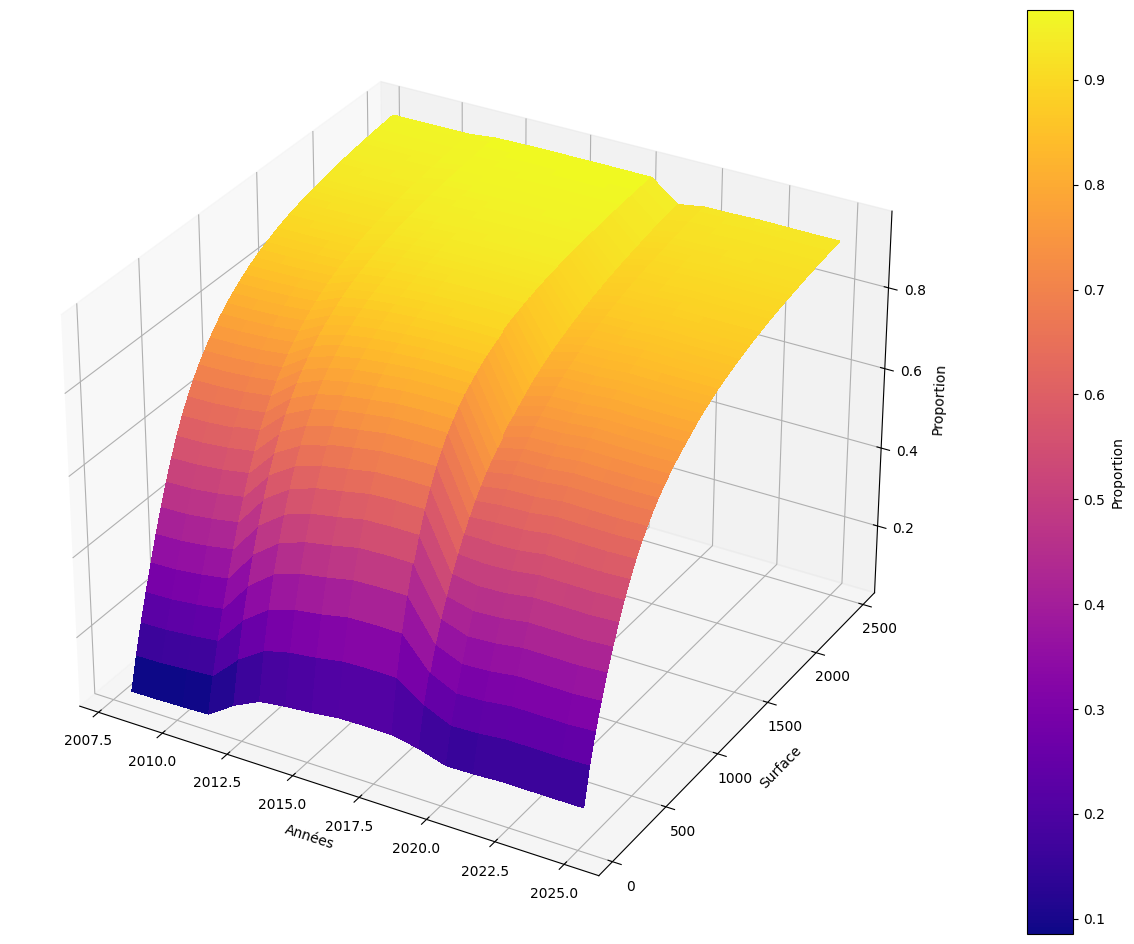

In [109]:
## Hors couleur

#########
######### Forme pour chaque année : un df trois colonnes : surf, année 
#########
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D 

nappe = pd.DataFrame(columns = ["Surface","Années","Proportion"])
distrib =list(np.array(list(range(1,50)))*50)
nappe.Surface = list(np.array(list(range(1,50)))*50)*(2025-2008+1) ## Le nombre d'années
nappe.Années = [i for i in range(2008, 2026) for _ in range(len(distrib))]

for an in range(2008,2026):
    prop = [] ## vecteur des proportions inféreures ou égales
    surf_vec = gdf[gdf.Annee == an].geometry.area
    for surface in distrib:
        prop.append(len(surf_vec[surf_vec<surface])/len(surf_vec))
    nappe.loc[nappe.Années == an,"Proportion"] = prop
nappe

tab = nappe.pivot_table(index='Surface', columns='Années', values='Proportion')
X, Y = np.meshgrid(tab.columns.values, tab.index.values)
Z = tab.values

fig = plt.figure(figsize=(24, 12))
ax = fig.add_subplot(111, projection='3d')

# Couleurs contrôlées par Z
surf = ax.plot_surface(X, Y, Z,cmap=cm.plasma,     # <- change ici : 'viridis', 'plasma', 'inferno', 'cividis', ...
                       linewidth=0,
                       antialiased=False)  # nappe
fig.colorbar(surf, ax=ax, label="Proportion") 
ax.set_xlabel("Années"); ax.set_ylabel("Surface"); ax.set_zlabel("Proportion")
plt.show()

De ce qui précède, on voit qu'en prenant une surface de 500m^2, il nous reste environ 40% des bâtiments. Cela peut reste satisfaisant. Pour 200m^2, il resterait 40%


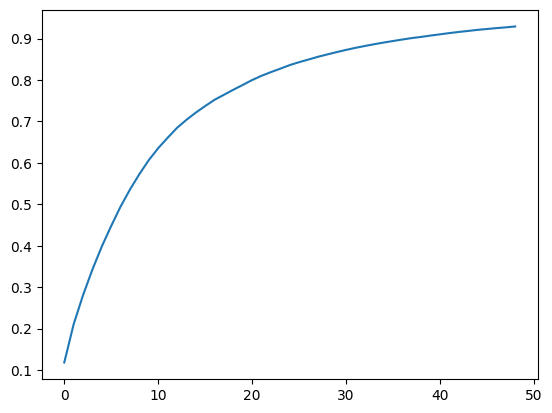

In [112]:
plt.plot(prop)

Distrib en 2025, l'axe x est à multiplier par 50 pour obtenir la surface

# Etude pour les bâtiments d'aire supérieure à 200m^2

On plot toutes les stat desc uniquement en conservant les batiments de plus de 200m^2

In [116]:
#### département 1 à 20

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg")
gdf = gdf[gdf.geometry.area >200]

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf1 = []
nbclust1 = []
nbmeta1 = []
nbisole1 = []
nbconv1 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat1 = []
for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf1.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust1.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta1.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole1.append(stat["n_noise_lvl1"])

    ## nb batiments
    nbbat1.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    # On commence par merger gdf meta et meta moins1 sur id pour rajouter l'id clu
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv1.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 21 à 40

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_21_40.gpkg")
gdf = gdf[gdf.geometry.area >200]


## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf2 = []
nbclust2 = []
nbmeta2 = []
nbisole2 = []
nbconv2 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf2.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust2.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta2.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole2.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv2.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 41 à 60

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_41_60.gpkg")
gdf = gdf[gdf.geometry.area >200]


## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf3 = []
nbclust3 = []
nbmeta3 = []
nbisole3 = []
nbconv3 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf3.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust3.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta3.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole3.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv3.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

#### département 61 à 80

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg")
gdf = gdf[gdf.geometry.area >200]


## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf4 = []
nbclust4 = []
nbmeta4 = []
nbisole4 = []
nbconv4 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf4.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust4.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta4.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole4.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv4.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))


#### département 81 à 99

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")
gdf = gdf[gdf.geometry.area >200]


## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf5 = []
nbclust5 = []
nbmeta5 = []
nbisole5 = []
nbconv5 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat5 = []

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN2(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN2(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des indus
    surf5.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust5.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta5.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole5.append(stat["n_noise_lvl1"])

    ## nb bat 
    nbbat5.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard
    gdf_meta_moins1.rename(columns={"id_meta_cluster": "id_meta_cluster_moins"}, inplace=True)
    gdf_meta = gdf_meta.merge(gdf_meta_moins1[["ID", "id_meta_cluster_moins"]], on="ID", how="left")
    nbconv5.append(len(gdf_meta[(gdf_meta.id_meta_cluster != -1) & (gdf_meta.id_meta_cluster_moins == -1)])/len(gdf_meta[gdf_meta.id_meta_cluster_moins == -1]))

##### On somme et on fait les statistiques descriptives

## nombre clusters
nbclust = [sum(x) for x in zip(nbclust1, nbclust2, nbclust3, nbclust4, nbclust5)]

## nombre de meta clusters
nbmeta = [sum(x) for x in zip(nbmeta1, nbmeta2, nbmeta3, nbmeta4, nbmeta5)]

## surface totale
surf = [sum(x) for x in zip(surf1, surf2, surf3, surf4, surf5)]

## nombre d'isolés
nbisole = [sum(x) for x in zip(nbisole1, nbisole2, nbisole3, nbisole4, nbisole5)]

## Nombre de conversions
nbconv = [sum(x) for x in zip(nbconv1, nbconv2, nbconv3, nbconv4, nbconv5)]


Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg ...


KeyboardInterrupt: 

In [ ]:
plt.plot(nbclust)

In [ ]:
plt.plot(nbmeta)

In [ ]:
plt.plot(surf)

In [ ]:
plt.plot(nbisole)

In [ ]:
plt.plot(nbconv)